Logistic Regression thì dự đoán xác suất (phân loại nhị phân) chẳng hạn dự đoán email spam or not spam, sinh viên pass hoặc fail dự đoán Yes hoặc No

## Bài toán: giờ ôn thi và kết quả thi

Giả sử có 10 sinh viên, mỗi người ôn từ 0 đến 6 giờ. Câu hỏi: số giờ ôn thi ảnh hưởng thế nào đến pass probability?

Đây là Logistic Regression vì đáp án không phải một con số liên tục như doanh thu. Đáp án chỉ có hai nhãn: pass hoặc fail.

| #Hours | 0.5 | 0.75 | 1.75 | 4.25 | 3.5 | 2 | 4.75 | 5.5 | 2.75 | 1 |
| --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- |
| #Pass | 0 | 0 | 1 | 1 | 1 | 0 | 1 | 1 | 1 | 0 |

- #Hours là số giờ ôn, đây là feature.
- #Pass là kết quả thi, đây là label. 0 là fail, 1 là pass.

Xếp lại theo số giờ để dễ thấy quy luật:

| Giờ ôn | 0.5 | 0.75 | 1 | 1.75 | 2 | 2.75 | 3.5 | 4.25 | 4.75 | 5.5 |
| --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- |
| Pass? | 0 | 0 | 0 | 1 | 0 | 1 | 1 | 1 | 1 | 1 |

Ôn ít, từ 0.5 đến 1 giờ, thì fail. Ôn từ 2.75 giờ trở lên thì pass. Ở giữa có một chỗ không thẳng: 1.75 giờ vẫn pass, nhưng 2 giờ lại fail. Vì vậy mô hình không kẻ một mốc cứng. Nó đoán pass probability, một số từ 0 đến 1. Giờ ôn càng nhiều, pass probability càng cao.

## Vì sao Linear Regression không áp dụng được

Chấm cam là fail, chấm xanh là pass, đường vàng là hồi quy tuyến tính.

Linear Regression không phù hợp vì:

1. Nhãn chỉ có 0 hoặc 1, nhưng đường đoán số lẻ. Ở 4 giờ nó đoán 0.91, trong khi nhãn pass là 1.
2. Đường không dừng trong khoảng 0 đến 1. Ở 5.5 giờ nó đoán 1.25. Xác suất không được lớn hơn 1.
3. Bạn ôn 1.75 giờ đã pass, nhưng đường chỉ đoán 0.39, dưới mốc 0.5, nên bị tính là fail.
4. Nếu thêm vài bạn ôn đến 20 giờ và pass, đường thẳng vẫn cứ tăng. Nó không thể vừa sát 0 với người fail, vừa sát 1 với người pass, rồi dừng ở 1. Nhiều bạn đã pass vẫn bị dự đoán là fail.

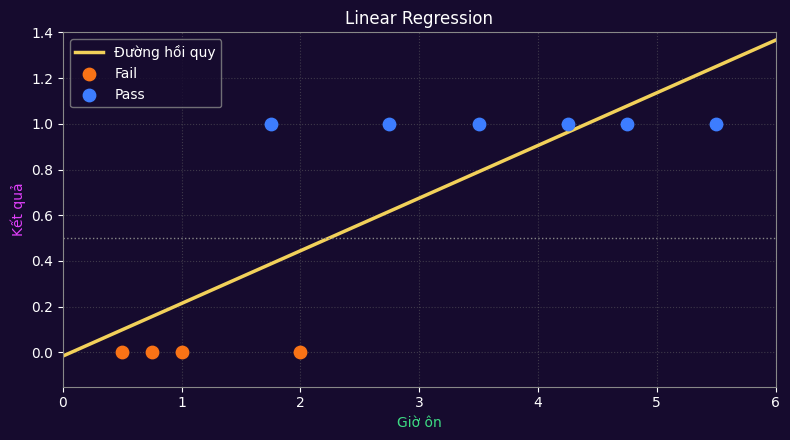

Ở 4 giờ, đường đoán 0.91
Ở 5.5 giờ, đường đoán 1.25
Ở 1.75 giờ, đường đoán 0.39


In [27]:
import numpy as np
import matplotlib.pyplot as plt

hours = np.array([0.5, 0.75, 1.75, 4.25, 3.5, 2, 4.75, 5.5, 2.75, 1])
passed = np.array([0, 0, 1, 1, 1, 0, 1, 1, 1, 0])

intercept = -0.016067842
slope = 0.230305735
x_line = np.linspace(0, 6, 100)
y_line = intercept + slope * x_line

fig, ax = plt.subplots(figsize=(8, 4.5))
fig.patch.set_facecolor("#160b2e")
ax.set_facecolor("#160b2e")

ax.plot(x_line, y_line, color="#f2d15a", linewidth=2.5, label="Đường hồi quy", zorder=2)
ax.scatter(
    hours[passed == 0],
    passed[passed == 0],
    s=80,
    c="#f97316",
    zorder=3,
    label="Fail",
)
ax.scatter(
    hours[passed == 1],
    passed[passed == 1],
    s=80,
    c="#3d7dff",
    zorder=3,
    label="Pass",
)

ax.axhline(0.5, color="#888888", linestyle=":", linewidth=1)
ax.set_xlim(0, 6)
ax.set_ylim(-0.15, 1.4)
ax.set_xlabel("Giờ ôn", color="#3ddc84")
ax.set_ylabel("Kết quả", color="#e040fb")
ax.set_title("Linear Regression", color="white")
ax.tick_params(colors="white")
for spine in ax.spines.values():
    spine.set_color("#888888")
ax.grid(True, linestyle=":", color="#666666", alpha=0.5)
legend = ax.legend(facecolor="#160b2e", edgecolor="#888888")
for text in legend.get_texts():
    text.set_color("white")
fig.tight_layout()
plt.show()

print(f"Ở 4 giờ, đường đoán {intercept + slope * 4:.2f}")
print(f"Ở 5.5 giờ, đường đoán {intercept + slope * 5.5:.2f}")
print(f"Ở 1.75 giờ, đường đoán {intercept + slope * 1.75:.2f}")

## Sigmoid

Đường thẳng ở trên có thể ra số âm hoặc số lớn hơn 1. Pass probability thì phải nằm giữa 0 và 1. Hàm logistic, còn gọi là sigmoid, làm đúng việc đó. Sigmoid có nghĩa là hình chữ S.

$$f(x) = \frac{1}{1 + e^{-x}}$$

- Khi x rất âm, e mũ trừ x rất lớn, nên f(x) tiến về 0. Pass probability gần như bằng 0.
- Khi x = 0, f(0) = 1 / 2 = 0.5.
- Khi x rất dương, e mũ trừ x gần 0, nên f(x) tiến về 1 và không vượt quá 1.

Với bài ôn thi, giờ ôn càng nhiều thì x càng lớn, pass probability càng tiến tới 1. Giờ ôn ít thì xác suất tiến tới 0.

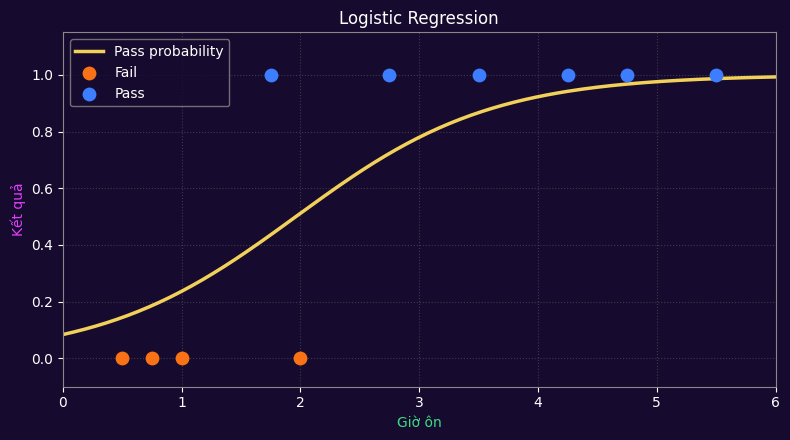

In [28]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression

hours = np.array([0.5, 0.75, 1.75, 4.25, 3.5, 2, 4.75, 5.5, 2.75, 1]).reshape(-1, 1)
passed = np.array([0, 0, 1, 1, 1, 0, 1, 1, 1, 0])

model = LogisticRegression()
model.fit(hours, passed)

x_line = np.linspace(0, 6, 200).reshape(-1, 1)
y_line = model.predict_proba(x_line)[:, 1]

fig, ax = plt.subplots(figsize=(8, 4.5))
fig.patch.set_facecolor("#160b2e")
ax.set_facecolor("#160b2e")

ax.plot(x_line, y_line, color="#f2d15a", linewidth=2.5, label="Pass probability", zorder=2)
ax.scatter(
    hours[passed == 0],
    passed[passed == 0],
    s=80,
    c="#f97316",
    zorder=3,
    label="Fail",
)
ax.scatter(
    hours[passed == 1],
    passed[passed == 1],
    s=80,
    c="#3d7dff",
    zorder=3,
    label="Pass",
)

ax.set_xlim(0, 6)
ax.set_ylim(-0.1, 1.15)
ax.set_xlabel("Giờ ôn", color="#3ddc84")
ax.set_ylabel("Kết quả", color="#e040fb")
ax.set_title("Logistic Regression", color="white")
ax.tick_params(colors="white")
for spine in ax.spines.values():
    spine.set_color("#888888")
ax.grid(True, linestyle=":", color="#666666", alpha=0.5)
legend = ax.legend(facecolor="#160b2e", edgecolor="#888888")
for text in legend.get_texts():
    text.set_color("white")
fig.tight_layout()
plt.show()

## Áp dụng Sigmoid

Lấy một sinh viên ôn 4.9 giờ. Nhãn thật y chỉ có hai giá trị: 1 là pass, 0 là fail.

Sau khi huấn luyện, giả sử mô hình ra:

$$Z = 4.9 - 2 = 2.9$$

Đưa Z vào sigmoid để được pass probability:

$$\hat{y} = \frac{1}{1 + e^{-2.9}} = 0.9477$$

Xác suất dự đoán khoảng 0.948, tức 94.8%. Vì xác suất này gần 1, mô hình kết luận #Pass = 1, sinh viên pass.

In [29]:
import math

hours = 4.9
z = hours - 2
probability = 1 / (1 + math.exp(-z))

print(f"Z = {z}")
print(f"Pass probability = {probability:.4f}")
print(f"Percent = {probability * 100:.1f}%")
print("#Pass = 1" if probability >= 0.5 else "#Pass = 0")

Z = 2.9000000000000004
Pass probability = 0.9478
Percent = 94.8%
#Pass = 1


## Biến đổi bằng hàm Sigmoid

Phần tuyến tính vẫn tạo ra một số z, giống Linear Regression:

$$z = b + w_1 x_1 + w_2 x_2 + \ldots + w_N x_N$$

Với bài một đặc trưng là số giờ ôn, z = b + w nhân giờ. Ví dụ vừa rồi: z = -2 + 4.9 = 2.9.

Logistic Regression không lấy z làm đáp án. Nó đưa z qua hàm sigmoid:

$$\hat{y} = \sigma(z)$$

$$\sigma(z) = \hat{y} = \frac{1}{1 + e^{-z}}$$

ŷ là xác suất, luôn nằm giữa 0 và 1. Với z = 2.9 thì ŷ = 0.9477, khoảng 94.8%, nên kết luận pass.

## So sánh Logistic và Linear

| Đặc điểm | Linear Regression | Logistic Regression |
| --- | --- | --- |
| Mục tiêu | Dự đoán giá trị liên tục | Dự đoán xác suất, dùng để phân loại hai nhãn |
| Ví dụ trong bài | Doanh thu Starbucks theo số giờ mở cửa | Sinh viên pass hoặc fail theo số giờ ôn |
| Huấn luyện | Lặp nhiều vòng, code viết rõ epochs = 1000 | Cũng lặp nhiều vòng, nhưng nằm trong fit. Mặc định tối đa 100 vòng |

Công thức đầu ra của Linear Regression:

$$\hat{y} = \mathbf{w}^{T} \mathbf{x} + b$$

Công thức đầu ra của Logistic Regression:

$$\hat{y} = \sigma(\mathbf{w}^{T} \mathbf{x} + b)$$

Linear trả về một số có thể âm hoặc lớn hơn 1, như doanh thu 600 USD. Logistic đưa số đó qua sigmoid, nên kết quả nằm giữa 0 và 1, rồi mới kết luận pass hoặc fail.

Cả hai đều phải huấn luyện nhiều vòng để chỉnh weight và bias. Linear viết vòng lặp ra ngoài với epochs = 1000. Logistic gọi model.fit, thư viện tự lặp bên trong, mặc định tối đa 100 vòng và có thể dừng sớm khi sai số gần như không giảm nữa.

## Bài tập: khách hàng có mua hàng không

Một công ty muốn đoán một khách hàng có mua sản phẩm hay không, dựa trên tuổi (#Age). Dữ liệu thu được từ 10 khách hàng:

| #Age | 20 | 25 | 30 | 35 | 40 | 45 | 50 | 55 | 60 | 65 |
| --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- |
| #Buy | 0 | 0 | 0 | 1 | 1 | 1 | 0 | 0 | 0 | 0 |

0 là không mua. 1 là mua. Nhóm mua nằm ở tuổi 35, 40 và 45.

#### Hướng dẫn giải

Bước 1. Tính z với #Age = 48 bằng công thức:

$$z = -10 + 0.3 \times \text{Age} = -10 + 0.3 \times 48 = 4.4$$

Bước 2. Tính xác suất P(y = 1) bằng hàm sigmoid. Lấy e khoảng 2.718:

$$P(y = 1) = \frac{1}{1 + e^{-z}} = \frac{1}{1 + e^{-4.4}} \approx 0.9879$$

Bước 3. So với ngưỡng 0.5 để dự đoán. 1 nếu P lớn hơn hoặc bằng 0.5, 0 nếu P nhỏ hơn 0.5. 0.9879 lớn hơn 0.5, nên dự đoán #Buy = 1, khách hàng mua.

Ô code bên dưới huấn luyện Logistic Regression trên 10 khách này, in công thức z mà mô hình học được, rồi đoán cho tuổi 48.

In [30]:
import numpy as np
from sklearn.linear_model import LogisticRegression

X = np.array([[20], [25], [30], [35], [40], [45], [50], [55], [60], [65]])
y = np.array([0, 0, 0, 1, 1, 1, 0, 0, 0, 0])

model = LogisticRegression(solver="lbfgs")
model.fit(X, y)


LogisticRegression()

In [31]:
w_0 = model.intercept_[0]
w_1 = model.coef_[0][0]
print(f"z = {w_0:.4f} + {w_1:.4f} * #Age")

age_to_predict = np.array([[48]])
prob = model.predict_proba(age_to_predict)[0][1]
prediction = 1 if prob >= 0.5 else 0

print(f"Buy probability at age 48: {prob:.4f}")
print(f"Prediction: {'Buy' if prediction == 1 else 'Not buy'}")

z = -0.1184 + -0.0174 * #Age
Buy probability at age 48: 0.2777
Prediction: Not buy


#### intercept_ và coef_ nghĩa là gì

Hai số này ghép thành z trước khi đưa vào sigmoid:

$$z = \text{intercept\_} + \text{coef\_} \times \text{Age}$$

$$P(\text{mua}) = \frac{1}{1 + e^{-z}}$$

- intercept_ là bias, ký hiệu w0. Đó là giá trị của z khi tuổi bằng 0. Trong code, model.intercept_[0] lấy số này.
- coef_ là weight, ký hiệu w1. Tuổi tăng 1 thì z tăng thêm đúng bằng hệ số này. Trong code, model.coef_[0][0] lấy weight của đặc trưng tuổi.

Ví dụ nếu in ra z = -0.1184 + -0.0174 * #Age, thì intercept_ là -0.1184 và coef_ là -0.0174. Tuổi càng cao, z càng giảm một chút, nên xác suất mua cũng giảm.